In [102]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [103]:
def remove_specific_cycles(data_loader, indices_to_remove):
    """
    Excludes specific indices from every key in the dataset.
    indices_to_remove: list of integers (e.g., [1, 3, 6])
    """
    cleaned_data = {}
    
    for key in data_loader.files:
        original_list = list(data_loader[key])
        # Keep only the items whose index is NOT in our 'remove' list
        cleaned_data[key] = [
            cycle for i, cycle in enumerate(original_list) 
            if i not in indices_to_remove
        ]
        
    return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
    """
    Interpolates cycles for a specific leg/parameter and calculates mean/std.
    """
    key = f'{param_prefix}_{leg}'
    if key not in data_source:
        return None, None, None

    raw_cycles = data_source[key]
    normalized_list = []
    

    for j, cycle in enumerate(raw_cycles):
            
        x_old = np.linspace(0, 100, len(cycle))
        x_new = np.linspace(0, 100, norm_points)
        norm_cycle = np.interp(x_new, x_old, cycle)
        normalized_list.append(norm_cycle)
    
    if not normalized_list:
        return None, None, None

    norm_matrix = np.array(normalized_list)
    mean_vals = np.mean(norm_matrix, axis=0)
    std_vals = np.std(norm_matrix, axis=0)
    x_axis = np.linspace(0, 100, norm_points)

    return x_axis, mean_vals, std_vals

In [104]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}
    
    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 1) 
        if len(parts) < 2: continue
        
        terrain, sensor = parts[0], parts[1]
        
        if terrain not in reconstructed:
            reconstructed[terrain] = {}
        
        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        # This makes it compatible with your existing segment_all_trials output
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
        
    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 3 terrains from walking_terrain_datasets.npz


In [105]:
name_joints = ['FR_J1', 'FR_J2', 'FR_J3', 'FR_J4', 
 'BR_J1', 'BR_J2', 'BR_J3', 'BR_J4', 
 'FL_J1', 'FL_J2', 'FL_J3', 'FL_J4', 
 'BL_J1', 'BL_J2', 'BL_J3', 'BL_J4']

name_legs = ['FR', 'BR', 'FL', 'BL']

# Plot show

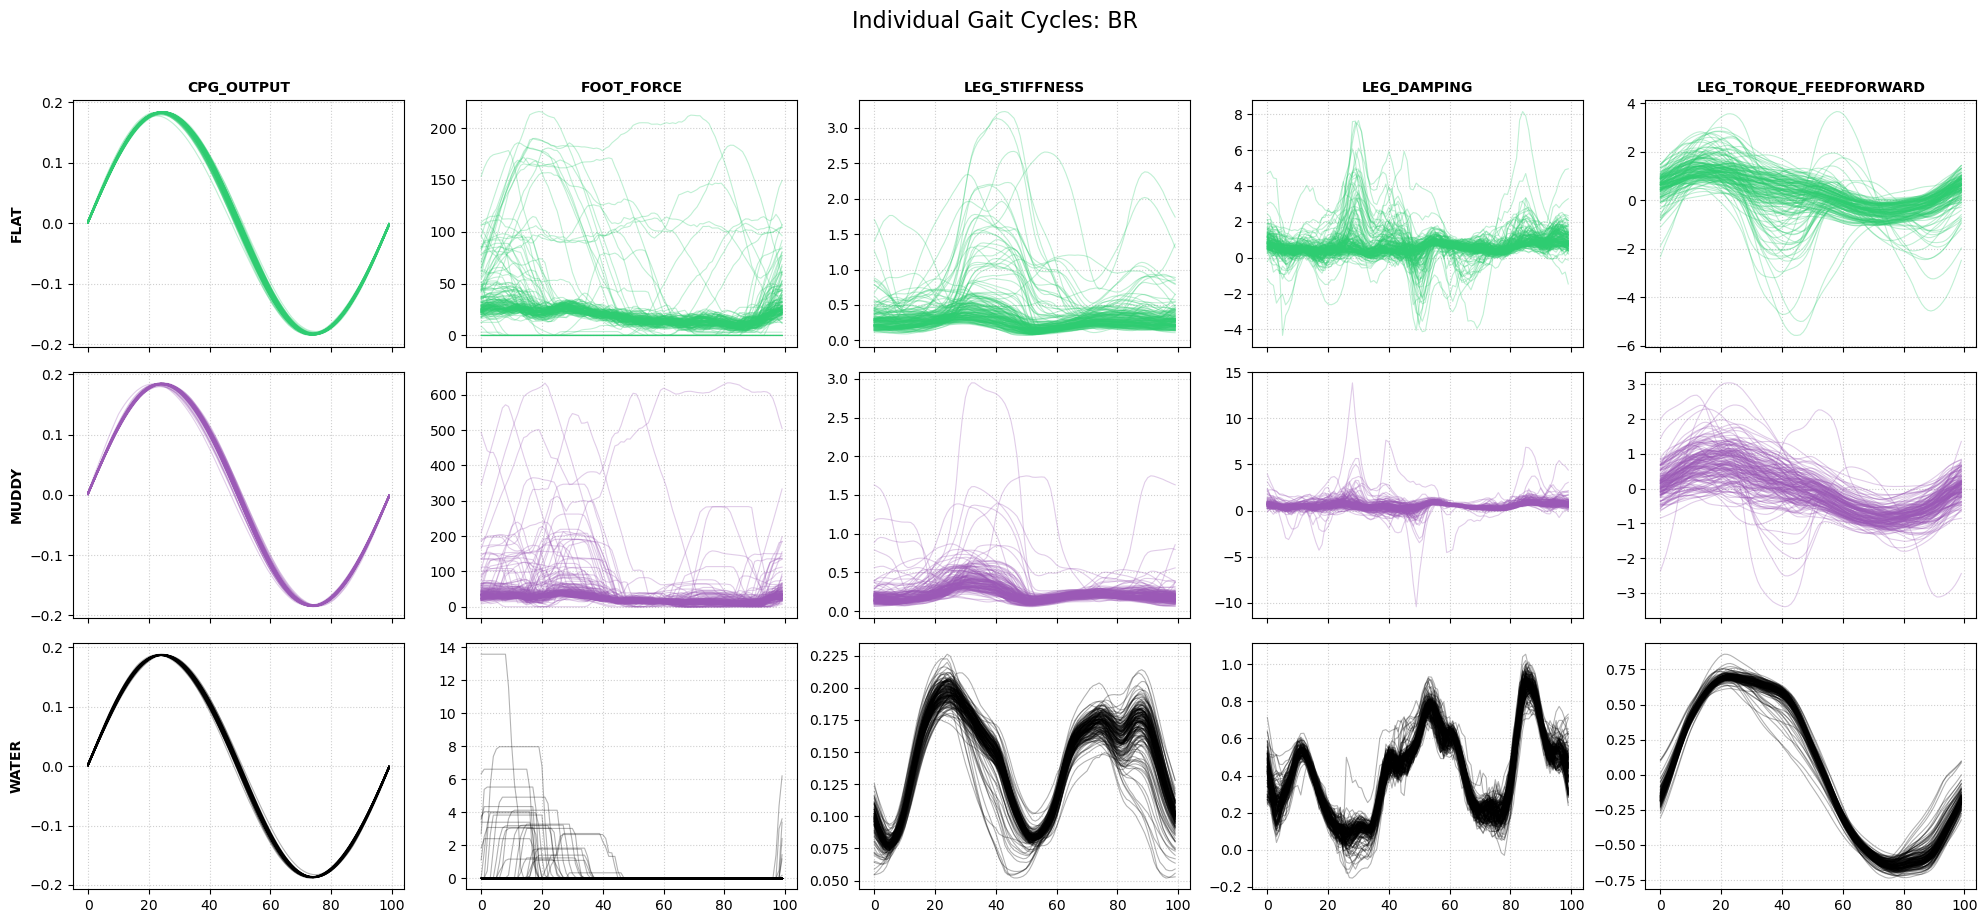

In [106]:
def plot_all_individual_cycles(cycle_results, sensor_list, feature_idx=0):
    """
    Plots every single cycle for every terrain to see the raw distribution.
    """
    terrains = list(cycle_results.keys())
    num_terrains = len(terrains)
    num_sensors = len(sensor_list)
    
    colors = {
        'flat': '#2ecc71', 'rough': '#e74c3c', 'sponge': '#3498db', 
        'sandy': '#f1c40f', 'muddy': '#9b59b6'
    }

    # Use a dynamic title based on the index
    # We try to find the name from the global scope, otherwise use the index number
    try:
        # Check if the first sensor in the list is a leg or joint sensor
        is_joint = 'joint' in sensor_list[0]
        feature_name = name_joints[feature_idx] if is_joint else name_legs[feature_idx]
    except (NameError, IndexError):
        feature_name = f"Index {feature_idx}"

    fig, axes = plt.subplots(num_terrains, num_sensors, 
                               figsize=(4 * num_sensors, 3 * num_terrains), 
                               sharex=True, squeeze=False) # squeeze=False keeps axes 2D (rows, cols)

    for t_idx, terrain in enumerate(terrains):
        for s_idx, sensor in enumerate(sensor_list):
            ax = axes[t_idx, s_idx]
            
            # Use .get() to avoid KeyError if a sensor is missing for a terrain
            cycles = cycle_results.get(terrain, {}).get(sensor, [])
            
            if not cycles or len(cycles) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
                continue
            
            color = colors.get(terrain, 'black')
            
            # Plot every single cycle
            for cycle in cycles:
                # cycle shape is (100, num_features)
                ax.plot(cycle[:, feature_idx], color=color, alpha=0.3, linewidth=0.8)
            
            # Formatting titles only for the top row
            if t_idx == 0:
                ax.set_title(f"{sensor.upper()}", fontsize=10, fontweight='bold')
            
            # Formatting labels only for the first column
            if s_idx == 0:
                ax.set_ylabel(f"{terrain.upper()}", fontsize=10, fontweight='bold')
            
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Individual Gait Cycles: {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- Execution ---
sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
plot_all_individual_cycles(dataset, sensors_to_plot, feature_idx=1)

In [107]:

def plot_all_sensors_comparison(cycle_results, sensor_list, feature_index=0, feature_name="Leg 0"):
    """
    Creates a vertical stack of subplots comparing multiple sensors across all terrains.
    """
    terrains = list(cycle_results.keys())
    colors = {'flat': 'green', 'rough': 'red', 'water': 'blue', 'sandy': 'orange', 'muddy': 'brown'}
    
    num_sensors = len(sensor_list)
    fig, axes = plt.subplots(num_sensors, 1, figsize=(5, 3 * num_sensors), sharex=True)
    
    # Ensure axes is iterable even if there's only one sensor
    if num_sensors == 1:
        axes = [axes]

    for i, sensor_name in enumerate(sensor_list):
        ax = axes[i]
        
        for terrain in terrains:
            # Check if data exists for this terrain/sensor combo
            cycles = cycle_results.get(terrain, {}).get(sensor_name, [])
            if not cycles:
                continue
                
            data_stack = np.stack(cycles)
            feature_data = data_stack[:, :, feature_index]
            
            mean_traj = np.mean(feature_data, axis=0)
            std_traj = np.std(feature_data, axis=0)
            
            x = np.arange(100)
            color = colors.get(terrain, 'black')
            
            ax.plot(x, mean_traj, label=terrain.capitalize(), color=color, linewidth=2)
            ax.fill_between(x, mean_traj - std_traj, mean_traj + std_traj, color=color, alpha=0.1)

        ax.set_ylabel("Value")
        ax.set_title(f"{sensor_name.replace('_', ' ').upper()}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Only put the legend on the top plot to keep it clean
        if i == 0:
            ax.legend(loc='upper right', ncol=2, fontsize='small')

    plt.xlabel("Gait Cycle (%)")
    plt.suptitle(f"Comparison Across Terrains - {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig("terrain_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

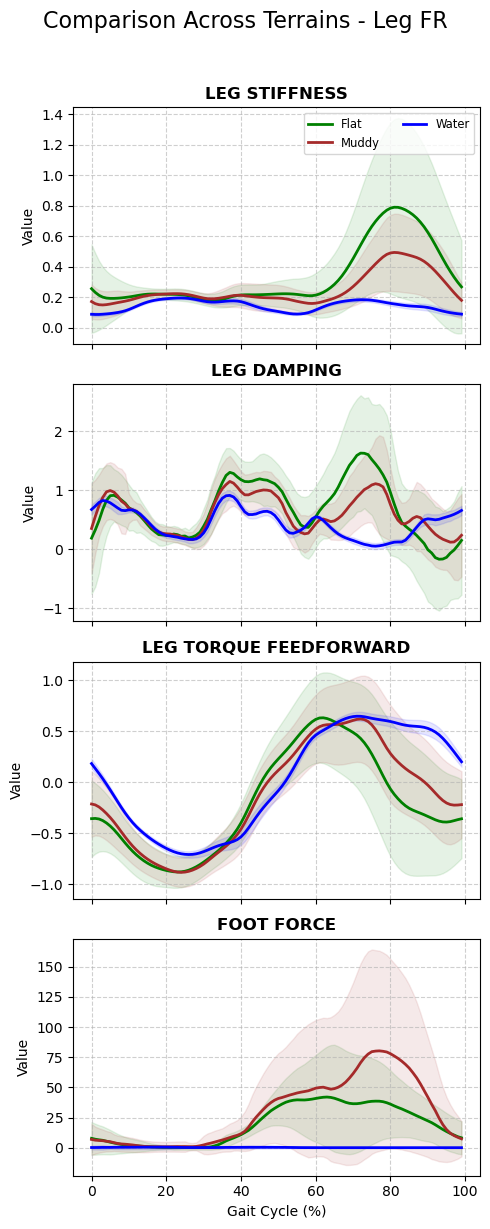

In [108]:
# List the sensors you want to visualize from the loaded file
sensors_to_plot = [
    'leg_stiffness', 
    'leg_damping', 
    'leg_torque_feedforward', 
    'foot_force'
]

# Use your previous subplot function
# Ensure name_legs is defined in your current environment
plot_all_sensors_comparison(
    dataset, 
    sensors_to_plot, 
    feature_index=0, 
    feature_name=f"Leg {name_legs[0]}"
)

# Train Process

In [109]:
import numpy as np
import random

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
    """
    Splits the gait cycle dataset into training and testing sets.
    Safely handles sensors with mismatched cycle counts.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
        # This ensures we don't try to access an index that doesn't exist for a sensor
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        
        # 2. Generate indices based on the shortest sensor stream
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        train_set[terrain] = {}
        test_set[terrain] = {}

        # 3. Distribute cycles
        for sensor in dataset[terrain].keys():
            all_cycles = dataset[terrain][sensor]
            # We only take the cycles up to min_cycles to stay synchronized
            train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
            test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
            
        print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
              f"({len(train_indices)} train, {len(test_indices)} test)")

    return train_set, test_set

# --- Execution ---
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.3)

Terrain FLAT: Used 62 synchronized cycles. (18 train, 44 test)
Terrain MUDDY: Used 59 synchronized cycles. (17 train, 42 test)
Terrain WATER: Used 53 synchronized cycles. (15 train, 38 test)


In [110]:
import numpy as np

def format_for_esn(dataset_dict, terrain_to_id_map, sensor_order):
    """
    Converts the nested dictionary into flat X and y lists for the ESN.
    
    dataset_dict: The output from your split_gait_dataset function.
    terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
    sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
    """
    X_formatted = []
    y_formatted = []
    
    for terrain, sensors_data in dataset_dict.items():
        if terrain not in terrain_to_id_map:
            continue # Skip terrains we aren't training on
            
        label = terrain_to_id_map[terrain]
        
        # Get the number of cycles for this terrain (they are synchronized)
        n_cycles = len(sensors_data[sensor_order[0]])
        
        for i in range(n_cycles):
            # For cycle 'i', gather data from all 16 joints (K, D, tau)
            cycle_columns = []
            for sensor_name in sensor_order:
                # Ensure it's a numpy array
                sensor_array = np.array(sensors_data[sensor_name][i])
                
                # If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
                if len(sensor_array.shape) == 1:
                    sensor_array = sensor_array.reshape(-1, 1)
                    
                cycle_columns.append(sensor_array)
            
            # Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
            full_gait_matrix = np.hstack(cycle_columns)
            
            X_formatted.append(full_gait_matrix)
            y_formatted.append(label)
            
    return X_formatted, np.array(y_formatted)

In [115]:
from env_pred import SupervisedESN
import itertools
import numpy as np

# --- 1. Define your mappings to enforce consistency ---
# Assign an integer to each surface
TERRAIN_LABELS = {
    'flat': 0,
    'muddy': 1,
    'water': 2
}

# Define the STRICT order of your sensors. 
# (Replace these with the actual keys used in your dataset dictionary)
# Example: ['joint_1_K', 'joint_1_D', 'joint_1_tau', 'joint_2_K'...]
SENSOR_KEYS = list(dataset['flat'].keys()) 
# SENSOR_KEYS = ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb']
# SENSOR_KEYS = ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
SENSOR_KEYS = ['joint_torque_fb']
# SENSOR_KEYS = ['joint_torque_fb', 'foot_force']
# SENSOR_KEYS = ['foot_force']


print(SENSOR_KEYS)
# --- 2. Split the raw dataset ---
print("Splitting dataset...")
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=42)

# --- 3. Format for the ESN ---
print("\nFormatting data for ESN...")
X_train, y_train = format_for_esn(train_data, TERRAIN_LABELS, SENSOR_KEYS)
X_test, y_test = format_for_esn(test_data, TERRAIN_LABELS, SENSOR_KEYS)

print(f"Total Training Cycles: {len(X_train)}")
print(f"Total Testing Cycles: {len(X_test)}")
print(f"Input Matrix Shape: {X_train[0].shape}") # Should be roughly (90, 48)


# --- 4. Define the Hyperparameter Grid ---
print("\nSetting up Hyperparameter Grid Search...")

# You can adjust these lists based on how much time you have to train.
# Warning: n_reservoir > 1000 takes significantly longer to train (matrix inversion is O(N^3))
param_grid = {
    'n_reservoir': [100, 500, 1000], 
    'leak_rate': [0.1, 0.3, 0.5, 0.8],
    'spectral_radius': [0.8, 0.9, 0.95],
    'lambda_reg': [0.001, 0.01, 0.1]
}

# Generate all possible combinations
keys = param_grid.keys()
combinations = list(itertools.product(*param_grid.values()))

print(f"Total combinations to test: {len(combinations)}\n")


['joint_torque_fb']
Splitting dataset...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)

Formatting data for ESN...
Total Training Cycles: 86
Total Testing Cycles: 88
Input Matrix Shape: (100, 16)

Setting up Hyperparameter Grid Search...
Total combinations to test: 108



In [116]:

# --- 5. Run the Search ---
best_accuracy = 0.0
best_params = None
best_model = None

for i, values in enumerate(combinations):
    # Unpack current parameters
    params = dict(zip(keys, values))
    
    print(f"[{i+1}/{len(combinations)}] Testing: res={params['n_reservoir']}, leak={params['leak_rate']}, "
          f"sr={params['spectral_radius']}, lam={params['lambda_reg']}...")
    
    # Initialize and train
    model = SupervisedESN(
        n_reservoir=params['n_reservoir'], 
        leak_rate=params['leak_rate'], 
        spectral_radius=params['spectral_radius'], 
        lambda_reg=params['lambda_reg']
    )
    
    model.fit(X_train, y_train)
    
    # Evaluate
    correct = 0
    for j in range(len(X_test)):
        predicted_class, _ = model.predict(X_test[j])
        if predicted_class == y_test[j]:
            correct += 1
            
    accuracy = (correct / len(X_test)) * 100
    print(f"  -> Accuracy: {accuracy:.2f}%")
    
    # Check if this is the best model so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_params = params
        best_model = model  # Keep the trained model in memory

# --- 6. Report and Save the Best Model ---
print("\n" + "="*40)
print(f"🏆 BEST MODEL FOUND 🏆")
print(f"Accuracy: {best_accuracy:.2f}%")
print("Parameters:")
for k, v in best_params.items():
    print(f" - {k}: {v}")
print("="*40 + "\n")

# Save using a dynamic filename based on the best reservoir size
filename = f"env_pred_esn_best.npz"
best_model.save_model(filename)

[1/108] Testing: res=100, leak=0.1, sr=0.8, lam=0.001...
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 100)
  -> Accuracy: 81.82%
[2/108] Testing: res=100, leak=0.1, sr=0.8, lam=0.01...
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 100)
  -> Accuracy: 80.68%
[3/108] Testing: res=100, leak=0.1, sr=0.8, lam=0.1...
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 100)
  -> Accuracy: 78.41%
[4/108] Testing: res=100, leak=0.1, sr=0.9, lam=0.001...
Processing 86 gait cycles through the reservoir...
Solving for Readout Weights using Ridge Regression...
ESN Training complete. Readout weight shape: (3, 100)
  -> Accuracy: 84.09%
[5/108] Testing: res=100, leak=0.1, sr=0.9, lam=0.0

Booting up ESN Controller...

[SUCCESS] ESN Model loaded from: 'env_pred_esn_best_joint_tor.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 500 neurons
   • Leak Rate:      0.8
   • Target Classes: 3

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (500, 16)
   • W_res (Reservoir Dynamics): (500, 500)
   • W_out (Reservoir -> Output): (3, 500)
----------------------------------------


Evaluating on unseen Test Set...
Test Accuracy: 88.64%


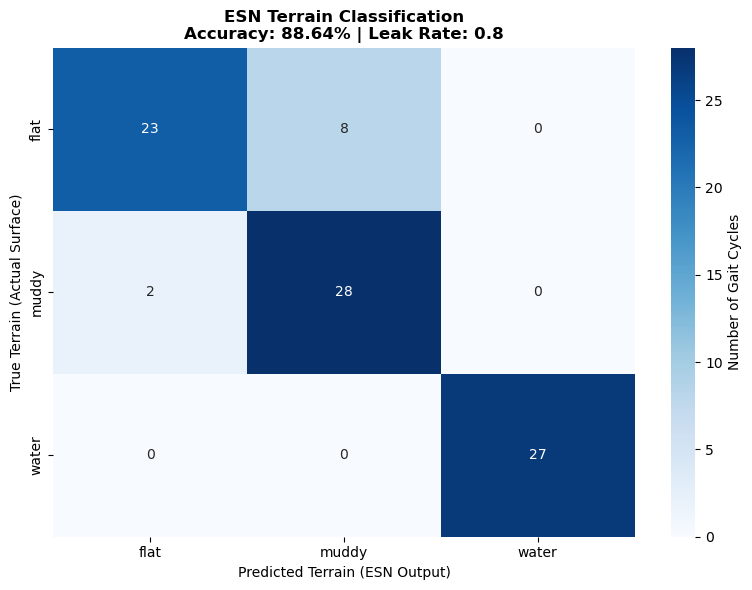

In [117]:
import numpy as np
from env_pred import SupervisedESN  # Assuming your class is saved in env_pred.py
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# ==========================================
# 1. LOAD THE MODEL
# ==========================================
print("Booting up ESN Controller...")

# Initialize an empty model (initial parameters don't matter, they get overwritten)
model = SupervisedESN()

# Load the weights from the file generated by your Grid Search
# (Make sure to update this filename to match your best model)
MODEL_FILENAME = "env_pred_esn_best_joint_tor.npz" 
model.load_model(MODEL_FILENAME)

# ==========================================
# 2. DEFINE YOUR MAPPINGS
# ==========================================
# Create a reverse mapping to turn the integer back into a readable string
ID_TO_TERRAIN = {
    0: 'flat',
    1: 'muddy',
    2: 'water'
}

# ==========================================
# 3. REAL-TIME DATA SIMULATION
# ==========================================

# --- 5. Evaluate on the Test Set ---
print("\nEvaluating on unseen Test Set...")
y_pred = []

# Collect all predictions
for i in range(len(X_test)):
    predicted_class, confidence = model.predict(X_test[i])
    y_pred.append(predicted_class)

# Convert to numpy array for fast comparison
y_pred = np.array(y_pred)

# Calculate Accuracy
correct = np.sum(y_pred == y_test)
accuracy = (correct / len(X_test)) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

# --- Generate Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_pred)

# Extract terrain names in the correct ID order (0, 1, 2)
terrain_names = [k for k, v in sorted(TERRAIN_LABELS.items(), key=lambda item: item[1])]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=terrain_names, 
            yticklabels=terrain_names,
            cbar_kws={'label': 'Number of Gait Cycles'})

plt.title(f'ESN Terrain Classification\nAccuracy: {accuracy:.2f}% | Leak Rate: {model.leak_rate}', fontweight='bold')
plt.ylabel('True Terrain (Actual Surface)')
plt.xlabel('Predicted Terrain (ESN Output)')
plt.tight_layout()
plt.show()

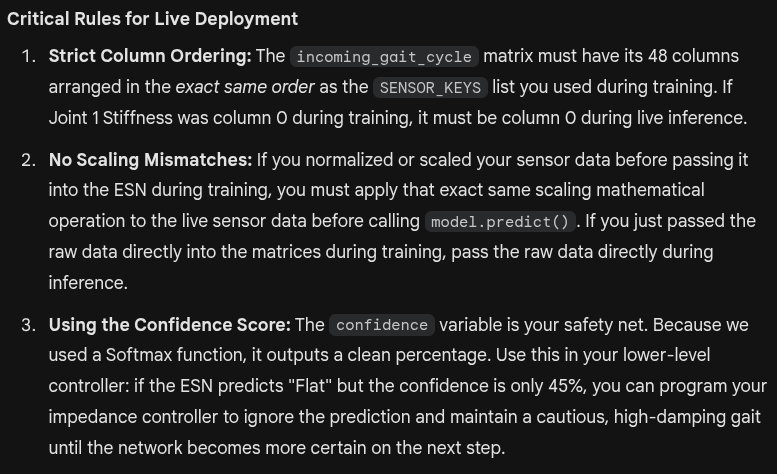